# Machine Learning Assignment - Spam Classification



### Part 1: Introduction and Dataset Overview

### Student Details
- **Name:** Liza T
- **ID:** 7558

### About the Dataset
The SMS Spam Collection Dataset contains 5,574 SMS messages
labeled as spam or ham (not spam).
This is a Binary Classification problem - we train a model
to classify each message into one of two classes: spam or ham.
The quality metric used is F1 Score on the spam class.
The goal is to build a model that can automatically detect spam messages.

### AI Assistance Used
- Tool: Claude AI (claude.ai)
- Purpose: Help with code structure, explanations, and debugging
- Prompts used: Asked for help building Naive Bayes from scratch,
  understanding TF-IDF, and structuring the notebook

In [54]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import KFold


In [55]:
# Download dataset from Kaggle
!pip install kaggle

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Machine_Learning_Assignment/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print("Total messages:", len(df))
df.head()

Total messages: 5572


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [82]:
# Split data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("\nFirst 5 rows of train:")
display(train_df.head())
print("\nFirst 5 rows of test:")
display(test_df.head())

Train size: 4457
Test size: 1115

First 5 rows of train:


,label,message
1978,ham,No I'm in the same boat. Still here at my moms...
3989,spam,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3935,ham,They r giving a second chance to rahul dengra.
4078,ham,O i played smash bros &lt;#&gt; religiously.
4086,spam,PRIVATE! Your 2003 Account Statement for 07973...



First 5 rows of test:


,label,message
3245,ham,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
944,ham,I sent my scores to sophas and i had to do sec...
1044,spam,We know someone who you know that fancies you....
2484,ham,Only if you promise your getting out as SOON a...
812,spam,Congratulations ur awarded either å£500 of CD ...


## Part 2 - Feature Engineering (Text to Numbers)

In this section, we convert raw text messages into numerical features
that the machine learning algorithm can process.

We use the TF-IDF (Term Frequency - Inverse Document Frequency) method:

- Term Frequency (TF): measures how often a word appears in a message.
- Inverse Document Frequency (IDF): reduces the weight of words that
  appear in many messages (like "the", "is", "and").
- The combination gives higher scores to words that are
  important in a specific message but rare across all messages.

This method is particularly effective for text classification tasks
because it highlights distinctive words like "FREE", "WIN", "PRIZE"
that are strong indicators of spam messages.

The output is a numerical matrix where each row represents a message
and each column represents a word from our vocabulary.

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Apply on train
X_train = vectorizer.fit_transform(train_df['message'])
y_train = train_df['label']

# Apply on test
X_test = vectorizer.transform(test_df['message'])
y_test = test_df['label']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4457, 7735)
Test shape: (1115, 7735)


In [84]:
# Show 3 examples from train
print("=== 3 Examples from Train ===\n")
for i in range(3):
    print(f"Message {i+1}: {train_df['message'].iloc[i]}")
    print(f"Label: {train_df['label'].iloc[i]}")
    print(f"Number of features: {X_train[i].nnz}")
    print("---")

# Show 3 examples from test
print("\n=== 3 Examples from Test ===\n")
for i in range(3):
    print(f"Message {i+1}: {test_df['message'].iloc[i]}")
    print(f"Label: {test_df['label'].iloc[i]}")
    print(f"Number of features: {X_test[i].nnz}")
    print("---")

=== 3 Examples from Train ===

Message 1: No I'm in the same boat. Still here at my moms. Check me out on yo. I'm half naked.
Label: ham
Number of features: 17
---
Message 2: (Bank of Granite issues Strong-Buy) EXPLOSIVE PICK FOR OUR MEMBERS *****UP OVER 300% *********** Nasdaq Symbol CDGT That is a $5.00 per..
Label: spam
Number of features: 21
---
Message 3: They r giving a second chance to rahul dengra.
Label: ham
Number of features: 7
---

=== 3 Examples from Test ===

Message 1: Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens
Label: ham
Number of features: 11
---
Message 2: I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones
Label: ham
Number of features: 31
---
Message 3: We know someone who you know that fanci

## Part 3 - Naive Bayes Algorithm Implementation

Naive Bayes is a probability-based classification algorithm.

Step 1 - Learning from training data:
The algorithm reads thousands of messages and looks for patterns.
For example:
- The word "FREE" appears 200 times in spam and only 3 times in ham.
- The word "WIN" appears 150 times in spam and only 2 times in ham.

Step 2 - A new message arrives:
When we get a new message like "You WIN a FREE prize!",
the algorithm calculates two probabilities:
- What is the probability this message is spam?
- What is the probability this message is ham?

Step 3 - Making a decision:
The algorithm compares both probabilities and picks the higher one.
In this case, spam wins because "FREE" and "WIN" are strong spam indicators.

Parameters:
- alpha: a smoothing value that prevents the probability
  from becoming zero when a word has never been seen before.
  (default = 1.0, lower values like 0.1 work better for this dataset)

In [85]:
import numpy as np

class NaiveBayes:
    def __init__(self, alpha=1.0):
        # alpha is for smoothing - prevents zero probabilities
        self.alpha = alpha

    def train(self, X, y):
        # Count how many spam and ham messages
        self.classes = np.unique(y)
        self.class_probs = {}
        self.feature_probs = {}

        for c in self.classes:
            # Get all messages of this class
            X_c = X[y == c]

            # Probability of this class (ham or spam)
            self.class_probs[c] = X_c.shape[0] / X.shape[0]

            # Probability of each word in this class
            word_counts = np.array(X_c.sum(axis=0)).flatten()
            total_words = word_counts.sum()
            self.feature_probs[c] = (word_counts + self.alpha) / (total_words + self.alpha * X.shape[1])

    def predict(self, X):
        predictions = []

        for i in range(X.shape[0]):
            best_class = None
            best_score = float('-inf')

            for c in self.classes:
                # Calculate score for this class
                score = np.log(self.class_probs[c])
                score += X[i].dot(np.log(self.feature_probs[c]))

                if score > best_score:
                    best_score = score
                    best_class = c

            predictions.append(best_class)

        return np.array(predictions)

## Part 4 - Training the Model

In this step we train the final model using the best combination found
from all our experiments in Part 6:
- Feature Engineering: TF-IDF with Unigrams + Bigrams
- max_features: 7000
- alpha: 0.1
- min_df: 1
- No sampling needed

The model learns from all 4,457 training messages:
- Which words appear most often in spam messages.
- Which words appear most often in ham messages.
- What percentage of all messages are spam vs ham.

We also show how 3 example messages go through the feature engineering process.

In [86]:
# Create and train the model
model = NaiveBayes(alpha=1.0)
model.train(X_train, y_train.values)

print("Model trained successfully!")
print("Classes found:", model.classes)

Model trained successfully!
Classes found: ['ham' 'spam']


In [87]:
print("=== Feature Engineering Process on 3 Examples ===\n")

examples = train_df.head(3)

for i, (_, row) in enumerate(examples.iterrows()):
    print(f"--- Example {i+1} ---")
    print(f"Original message: {row['message']}")
    print(f"Label: {row['label']}")

    # Step 1: Vectorize
    example_vec = final_vec.transform([row['message']])
    print(f"After TF-IDF: {example_vec.nnz} unique words found")

    # Step 2: Predict
    pred = final_model.predict(example_vec)
    print(f"Model prediction: {pred[0]}")
    print(f"Correct: {pred[0] == row['label']}")
    print()

=== Feature Engineering Process on 3 Examples ===

--- Example 1 ---
Original message: No I'm in the same boat. Still here at my moms. Check me out on yo. I'm half naked.
Label: ham
After TF-IDF: 24 unique words found
Model prediction: ham
Correct: True

--- Example 2 ---
Original message: (Bank of Granite issues Strong-Buy) EXPLOSIVE PICK FOR OUR MEMBERS *****UP OVER 300% *********** Nasdaq Symbol CDGT That is a $5.00 per..
Label: spam
After TF-IDF: 24 unique words found
Model prediction: spam
Correct: True

--- Example 3 ---
Original message: They r giving a second chance to rahul dengra.
Label: ham
After TF-IDF: 6 unique words found
Model prediction: ham
Correct: True



## Part 5 - Testing the Model

In this step we test the final model on 1,115 unseen messages.
We use the best combination found in Part 6:
- Feature Engineering: TF-IDF with Unigrams + Bigrams
- max_features: 7000, alpha: 0.1, min_df: 1

We measure the model quality using F1 Score:
- Precision: out of all messages predicted as spam, how many were actually spam?
- Recall: out of all actual spam messages, how many did we correctly identify?
- F1 Score: the balance between precision and recall. Closer to 1.0 is better.

First we show how 3 test messages go through the feature engineering process,
then we show the first 5 predictions and the final quality score.


In [88]:
print("=== Feature Engineering Process on 3 Test Examples ===\n")

examples = test_df.head(3)

for i, (_, row) in enumerate(examples.iterrows()):
    print(f"--- Example {i+1} ---")
    print(f"Original message: {row['message']}")
    print(f"Label: {row['label']}")
    example_vec = final_vec.transform([row['message']])
    print(f"After TF-IDF: {example_vec.nnz} unique words found")
    pred = final_model.predict(example_vec)
    print(f"Model prediction: {pred[0]}")
    print(f"Correct: {pred[0] == row['label']}")
    print()

print("=== First 5 Predictions on Test Set ===\n")
y_pred_final = final_model.predict(X_test_final)
for i in range(5):
    print(f"Message: {test_df['message'].iloc[i]}")
    print(f"Real label: {test_df['label'].iloc[i]}")
    print(f"Predicted: {y_pred_final[i]}")
    print("---")

f1_final = f1_score(y_test, y_pred_final, pos_label='spam')
print(f"\n=== Final Model Quality ===")
print(f"F1 Score: {f1_final:.4f}")
print(classification_report(y_test, y_pred_final))

=== Feature Engineering Process on 3 Test Examples ===

--- Example 1 ---
Original message: Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens
Label: ham
After TF-IDF: 9 unique words found
Model prediction: ham
Correct: True

--- Example 2 ---
Original message: I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones
Label: ham
After TF-IDF: 35 unique words found
Model prediction: ham
Correct: True

--- Example 3 ---
Original message: We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p
Label: spam
After TF-IDF: 20 unique words found
Model prediction: spam
Correct: True

=== First 5 Predictions on Test Set ===

Message: Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 a

## Summary

In this assignment we built a spam detection model using Naive Bayes algorithm.

### What we did:
1. Loaded the SMS Spam Collection Dataset (5572 messages)
2. Split the data into train (4457) and test (1115)
3. Converted text to numbers using TF-IDF
4. Implemented Naive Bayes algorithm from scratch
5. Trained the model and tested it

### Results:
- Accuracy: 96%
- F1 Score for spam: 0.84
- The model successfully detects most spam messages

## Part 6A - Grid Search with 5-Fold Cross Validation

In this section, we combine Grid Search and K-Fold Cross Validation
to find the most reliable and optimal parameters for our model.

Grid Search tests all 9 possible combinations (Cartesian product) of:
- TF-IDF max_features: [1000, 3000, 7000]
- Naive Bayes alpha: [0.1, 1.0, 5.0]

Each combination is tested 5 times on different parts of the training set.
The final score for each combination is the average of all 5 folds.
Total runs: 9 combinations x 5 folds = 45 runs.

Results:
- Best combination: max_features=7000, alpha=0.1
- Best Average F1: 0.9416
- Worst combination: max_features=7000, alpha=5.0, F1=0.0967

Conclusion:
More words (7000) with less smoothing (alpha=0.1) gives the best results.
Heavy smoothing (alpha=5.0) significantly hurts performance.





In [65]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import pandas as pd

# All parameter combinations to test
tfidf_options = [1000, 3000, 7000]
alpha_options = [0.1, 1.0, 5.0]

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

print("=== Grid Search with 5-Fold Cross Validation ===\n")

# Test ALL combinations
for max_features in tfidf_options:
    for alpha in alpha_options:
        fold_scores = []

        # Run 5 folds for each combination
        for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
            fold_train = train_df.iloc[train_idx]
            fold_val = train_df.iloc[val_idx]

            # TF-IDF
            vec = TfidfVectorizer(max_features=max_features)
            X_tr = vec.fit_transform(fold_train['message'])
            X_val = vec.transform(fold_val['message'])

            # Train
            nb = NaiveBayes(alpha=alpha)
            nb.train(X_tr, fold_train['label'].values)

            # Validate
            preds = nb.predict(X_val)
            f1 = f1_score(fold_val['label'], preds, pos_label='spam')
            fold_scores.append(f1)

        # Average score of 5 folds
        avg_f1 = round(sum(fold_scores) / len(fold_scores), 4)

        results.append({
            'max_features': max_features,
            'alpha': alpha,
            'avg_f1_score': avg_f1
        })

        print(f"max_features={max_features}, alpha={alpha} → Average F1: {avg_f1}")

# Show all results sorted
print("\n=== All Results (sorted by F1 Score) ===")
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('avg_f1_score', ascending=False)
print(results_df.to_string(index=False))

# Show best combination
best = results_df.iloc[0]
print(f"\n=== Best Combination ===")
print(f"max_features: {int(best['max_features'])}")
print(f"alpha: {best['alpha']}")
print(f"Average F1: {best['avg_f1_score']}")

=== Grid Search with 5-Fold Cross Validation ===

max_features=1000, alpha=0.1 → Average F1: 0.9315
max_features=1000, alpha=1.0 → Average F1: 0.9023
max_features=1000, alpha=5.0 → Average F1: 0.7277
max_features=3000, alpha=0.1 → Average F1: 0.939
max_features=3000, alpha=1.0 → Average F1: 0.878
max_features=3000, alpha=5.0 → Average F1: 0.3799
max_features=7000, alpha=0.1 → Average F1: 0.9416
max_features=7000, alpha=1.0 → Average F1: 0.7979
max_features=7000, alpha=5.0 → Average F1: 0.0967

=== All Results (sorted by F1 Score) ===
 max_features  alpha  avg_f1_score
         7000    0.1        0.9416
         3000    0.1        0.9390
         1000    0.1        0.9315
         1000    1.0        0.9023
         3000    1.0        0.8780
         7000    1.0        0.7979
         1000    5.0        0.7277
         3000    5.0        0.3799
         7000    5.0        0.0967

=== Best Combination ===
max_features: 7000
alpha: 0.1
Average F1: 0.9416


## Part 6B - Feature Engineering Experiments

In this section, we experiment with different feature engineering methods
to improve our spam detection model.

### What are we comparing?

Method 1 - TF-IDF with Unigrams (single words):
Each message is represented by individual words.
Example: "Free cash prize" → ["Free", "cash", "prize"]

Method 2 - TF-IDF with Unigrams and Bigrams (word pairs):
Each message is represented by both single words AND pairs of words.
Example: "Free cash prize" → ["Free", "cash", "prize", "Free cash", "cash prize"]

Method 3 - TF-IDF with Unigrams and Bigrams + Special Preprocessing:
Same as Method 2, but with special preprocessing for spam detection:
- Convert to lowercase
- Replace phone numbers with PHONENUMBER token
- Replace money amounts with MONEYAMOUNT token
- Replace URLs with URL token

### Why Bigrams?
Some spam phrases are made of two words together, not just one word alone.
For example "click here" signals spam, but "click" and "here" alone are normal words.

### Why Preprocessing?
Spam messages often contain different phone numbers and money amounts.
By replacing them with tokens, the model learns the pattern instead of specific values.

### Methodology:
1. Extract features using all three methods.
2. Train Naive Bayes model on each method.
3. Run 5-Fold Cross Validation for reliable evaluation.
4. Compare results in a DataFrame table.

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import pandas as pd
import re

# Special preprocessing for spam detection
def preprocess(text):
    # Convert to lowercase
    text = text.lower()
    # Replace phone numbers with token
    text = re.sub(r'\d{10,}', 'PHONENUMBER', text)
    # Replace money amounts with token
    text = re.sub(r'£\d+|\$\d+|\d+p\b', 'MONEYAMOUNT', text)
    # Replace URLs with token
    text = re.sub(r'http\S+|www\S+', 'URL', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Feature engineering options to compare
fe_options = [
    {'name': 'TF-IDF Unigrams (no preprocessing)',
     'ngram_range': (1,1), 'max_features': 7000, 'preprocess': False},
    {'name': 'TF-IDF Unigrams + Bigrams (no preprocessing)',
     'ngram_range': (1,2), 'max_features': 7000, 'preprocess': False},
    {'name': 'TF-IDF Unigrams + Bigrams (with preprocessing)',
     'ngram_range': (1,2), 'max_features': 7000, 'preprocess': True},
]

alpha_options = [0.1, 1.0]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fe_results = []

print("=== Feature Engineering Experiments ===\n")

for fe in fe_options:
    for alpha in alpha_options:
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
            fold_train = train_df.iloc[train_idx].copy()
            fold_val = train_df.iloc[val_idx].copy()

            # Apply preprocessing if needed
            if fe['preprocess']:
                fold_train_msg = fold_train['message'].apply(preprocess)
                fold_val_msg = fold_val['message'].apply(preprocess)
            else:
                fold_train_msg = fold_train['message']
                fold_val_msg = fold_val['message']

            vec = TfidfVectorizer(
                max_features=fe['max_features'],
                ngram_range=fe['ngram_range']
            )

            X_tr = vec.fit_transform(fold_train_msg)
            X_val = vec.transform(fold_val_msg)

            nb = NaiveBayes(alpha=alpha)
            nb.train(X_tr, fold_train['label'].values)

            preds = nb.predict(X_val)
            f1 = f1_score(fold_val['label'], preds, pos_label='spam')
            fold_scores.append(f1)

        avg_f1 = round(sum(fold_scores) / len(fold_scores), 4)
        fe_results.append({
            'method': fe['name'],
            'alpha': alpha,
            'avg_f1_score': avg_f1
        })

        print(f"{fe['name']}, alpha={alpha} → Average F1: {avg_f1}")

fe_results_df = pd.DataFrame(fe_results)
fe_results_df = fe_results_df.sort_values('avg_f1_score', ascending=False)

print("\n=== All Results ===")
print(fe_results_df.to_string(index=False))

best_fe = fe_results_df.iloc[0]
print(f"\n=== Best Method ===")
print(f"Method: {best_fe['method']}")
print(f"Alpha: {best_fe['alpha']}")
print(f"Average F1: {best_fe['avg_f1_score']}")

=== Feature Engineering Experiments ===

TF-IDF Unigrams (no preprocessing), alpha=0.1 → Average F1: 0.9416
TF-IDF Unigrams (no preprocessing), alpha=1.0 → Average F1: 0.7979
TF-IDF Unigrams + Bigrams (no preprocessing), alpha=0.1 → Average F1: 0.9529
TF-IDF Unigrams + Bigrams (no preprocessing), alpha=1.0 → Average F1: 0.8533
TF-IDF Unigrams + Bigrams (with preprocessing), alpha=0.1 → Average F1: 0.9527
TF-IDF Unigrams + Bigrams (with preprocessing), alpha=1.0 → Average F1: 0.8806

=== All Results ===
                                        method  alpha  avg_f1_score
  TF-IDF Unigrams + Bigrams (no preprocessing)    0.1        0.9529
TF-IDF Unigrams + Bigrams (with preprocessing)    0.1        0.9527
            TF-IDF Unigrams (no preprocessing)    0.1        0.9416
TF-IDF Unigrams + Bigrams (with preprocessing)    1.0        0.8806
  TF-IDF Unigrams + Bigrams (no preprocessing)    1.0        0.8533
            TF-IDF Unigrams (no preprocessing)    1.0        0.7979

=== Best Method

### Results and Conclusion

Results summary:
- TF-IDF Unigrams, no preprocessing, alpha=0.1: F1 = 0.9416
- TF-IDF Unigrams + Bigrams, no preprocessing, alpha=0.1: F1 = 0.9529 (BEST)
- TF-IDF Unigrams + Bigrams, with preprocessing, alpha=0.1: F1 = 0.9527

Conclusion:
Adding Bigrams improved performance significantly (0.9416 → 0.9529).
Preprocessing had almost no effect (0.9529 → 0.9527).

This suggests that TF-IDF already handles most text normalization internally.
However, preprocessing with alpha=1.0 showed improvement (0.8533 → 0.8806),
meaning preprocessing helps more when the model uses heavier smoothing.

Best method: TF-IDF Unigrams + Bigrams without preprocessing, alpha=0.1

## Part 6C - Hyperparameter Experiments

In this section, we experiment with different hyperparameter values
to find the optimal configuration for our model.

We test two hyperparameters:

1. alpha (Naive Bayes smoothing parameter) - learned in class:
   Controls how much the model trusts rare words.
   - 0.1: trusts the data more, less smoothing
   - 1.0: balanced smoothing (default)
   - 5.0: heavy smoothing, ignores rare words

2. min_df (TF-IDF minimum document frequency) - NOT learned in class:
   Controls the minimum number of messages a word must appear in
   to be included in the vocabulary.
   - min_df=1: include ALL words, even if they appear only once
   - min_df=2: only include words that appear in at least 2 messages
   - min_df=5: only include words that appear in at least 5 messages
   
   Why is this useful for spam detection?
   Very rare words are often typos or unique identifiers in spam messages.
   By filtering them out, we reduce noise and focus on meaningful patterns.
   Higher min_df values create a cleaner but smaller vocabulary.

We test all 9 combinations (3 x 3) using Grid Search and 5-Fold Cross Validation.

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import pandas as pd

# Hyperparameter options to test
alpha_options = [0.1, 1.0, 5.0]
min_df_options = [1, 2, 5]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

hyper_results = []

print("=== Hyperparameter Experiments ===\n")

for alpha in alpha_options:
    for min_df in min_df_options:
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
            fold_train = train_df.iloc[train_idx]
            fold_val = train_df.iloc[val_idx]

            vec = TfidfVectorizer(
                max_features=7000,
                ngram_range=(1,2),
                min_df=min_df
            )

            X_tr = vec.fit_transform(fold_train['message'])
            X_val = vec.transform(fold_val['message'])

            nb = NaiveBayes(alpha=alpha)
            nb.train(X_tr, fold_train['label'].values)

            preds = nb.predict(X_val)
            f1 = f1_score(fold_val['label'], preds, pos_label='spam')
            fold_scores.append(f1)

        avg_f1 = round(sum(fold_scores) / len(fold_scores), 4)
        hyper_results.append({
            'alpha': alpha,
            'min_df': min_df,
            'avg_f1_score': avg_f1
        })

        print(f"alpha={alpha}, min_df={min_df} → Average F1: {avg_f1}")

hyper_results_df = pd.DataFrame(hyper_results)
hyper_results_df = hyper_results_df.sort_values('avg_f1_score', ascending=False)

print("\n=== All Results ===")
print(hyper_results_df.to_string(index=False))

best_hyper = hyper_results_df.iloc[0]
print(f"\n=== Best Combination ===")
print(f"Alpha: {best_hyper['alpha']}")
print(f"Min_df: {int(best_hyper['min_df'])}")
print(f"Average F1: {best_hyper['avg_f1_score']}")

=== Hyperparameter Experiments ===

alpha=0.1, min_df=1 → Average F1: 0.9529
alpha=0.1, min_df=2 → Average F1: 0.9521
alpha=0.1, min_df=5 → Average F1: 0.9462
alpha=1.0, min_df=1 → Average F1: 0.8533
alpha=1.0, min_df=2 → Average F1: 0.8579
alpha=1.0, min_df=5 → Average F1: 0.9045
alpha=5.0, min_df=1 → Average F1: 0.2322
alpha=5.0, min_df=2 → Average F1: 0.2353
alpha=5.0, min_df=5 → Average F1: 0.5996

=== All Results ===
 alpha  min_df  avg_f1_score
   0.1       1        0.9529
   0.1       2        0.9521
   0.1       5        0.9462
   1.0       5        0.9045
   1.0       2        0.8579
   1.0       1        0.8533
   5.0       5        0.5996
   5.0       2        0.2353
   5.0       1        0.2322

=== Best Combination ===
Alpha: 0.1
Min_df: 1
Average F1: 0.9529


### Results and Conclusion

Results summary:
- alpha=0.1, min_df=1 → F1: 0.9529 (BEST)
- alpha=0.1, min_df=2 → F1: 0.9521
- alpha=0.1, min_df=5 → F1: 0.9462
- alpha=1.0, min_df=5 → F1: 0.9045
- alpha=5.0, min_df=5 → F1: 0.5996

Conclusion:
- alpha=0.1 consistently outperforms higher alpha values.
  Less smoothing works better for this dataset.
- min_df=1 gives the best results, meaning that
  even rare words carry useful information for spam detection.
- Heavy smoothing (alpha=5.0) significantly hurts performance.

Best combination: alpha=0.1, min_df=1, Average F1=0.9529

## Part 6D - Handling Imbalanced Data

### The Problem
Our dataset has a severe class imbalance:
- Ham (normal messages): 3860 (86.6%)
- Spam messages: 597 (13.4%)

For every 1 spam message there are about 6 ham messages.
This can cause the model to ignore spam and just predict ham for everything.

### Our Strategy
We compare three approaches:

1. No sampling (baseline): use the data as-is.
2. Oversampling: duplicate spam messages to balance the classes.
3. Undersampling: remove ham messages to balance the classes.

All three are evaluated using 5-Fold Cross Validation.

In [68]:
# Check class distribution
print("=== Class Distribution ===")
print(train_df['label'].value_counts())
print("\nPercentages:")
print(train_df['label'].value_counts(normalize=True).round(3) * 100)

=== Class Distribution ===
label
ham     3860
spam     597
Name: count, dtype: int64

Percentages:
label
ham     86.6
spam    13.4
Name: proportion, dtype: float64


In [69]:
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
sampling_results = []

print("=== Imbalanced Data Experiments ===\n")

for sampling in ['none', 'oversample', 'undersample']:
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
        fold_train = train_df.iloc[train_idx].copy()
        fold_val = train_df.iloc[val_idx]

        if sampling == 'oversample':
            # Duplicate spam messages to match ham count
            spam_df = fold_train[fold_train['label'] == 'spam']
            ham_df = fold_train[fold_train['label'] == 'ham']
            spam_upsampled = spam_df.sample(len(ham_df), replace=True, random_state=42)
            fold_train = pd.concat([ham_df, spam_upsampled])

        elif sampling == 'undersample':
            # Reduce ham messages to match spam count
            spam_df = fold_train[fold_train['label'] == 'spam']
            ham_df = fold_train[fold_train['label'] == 'ham']
            ham_downsampled = ham_df.sample(len(spam_df), random_state=42)
            fold_train = pd.concat([spam_df, ham_downsampled])

        vec = TfidfVectorizer(max_features=7000, ngram_range=(1,2))
        X_tr = vec.fit_transform(fold_train['message'])
        X_val = vec.transform(fold_val['message'])

        nb = NaiveBayes(alpha=0.1)
        nb.train(X_tr, fold_train['label'].values)

        preds = nb.predict(X_val)
        f1 = f1_score(fold_val['label'], preds, pos_label='spam')
        fold_scores.append(f1)

    avg_f1 = round(sum(fold_scores) / len(fold_scores), 4)
    sampling_results.append({
        'sampling_method': sampling,
        'avg_f1_score': avg_f1
    })
    print(f"Sampling={sampling} → Average F1: {avg_f1}")

sampling_df = pd.DataFrame(sampling_results)
sampling_df = sampling_df.sort_values('avg_f1_score', ascending=False)
print("\n=== All Results ===")
print(sampling_df.to_string(index=False))

best_sampling = sampling_df.iloc[0]
print(f"\n=== Best Method ===")
print(f"Method: {best_sampling['sampling_method']}")
print(f"Average F1: {best_sampling['avg_f1_score']}")



=== Imbalanced Data Experiments ===

Sampling=none → Average F1: 0.9529
Sampling=oversample → Average F1: 0.943
Sampling=undersample → Average F1: 0.9021

=== All Results ===
sampling_method  avg_f1_score
           none        0.9529
     oversample        0.9430
    undersample        0.9021

=== Best Method ===
Method: none
Average F1: 0.9529


In [70]:
# Install imbalanced-learn for SMOTE
!pip install imbalanced-learn -q

In [71]:
from imblearn.over_sampling import SMOTE

print("=== Adding SMOTE (Synthetic Minority Oversampling) ===\n")

smote_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
    fold_train = train_df.iloc[train_idx].copy()
    fold_val = train_df.iloc[val_idx]

    vec = TfidfVectorizer(max_features=7000, ngram_range=(1,2))
    X_tr = vec.fit_transform(fold_train['message'])
    X_val = vec.transform(fold_val['message'])

    # Apply SMOTE - creates synthetic spam examples
    smote = SMOTE(random_state=42)
    X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, fold_train['label'].values)

    nb = NaiveBayes(alpha=0.1)
    nb.train(X_tr_smote, y_tr_smote)

    preds = nb.predict(X_val)
    f1 = f1_score(fold_val['label'], preds, pos_label='spam')
    smote_scores.append(f1)

avg_smote = round(sum(smote_scores) / len(smote_scores), 4)
print(f"SMOTE Average F1: {avg_smote}")

# Add SMOTE to results table
smote_row = pd.DataFrame([{'sampling_method': 'SMOTE', 'avg_f1_score': avg_smote}])
sampling_df_final = pd.concat([sampling_df, smote_row])
sampling_df_final = sampling_df_final.sort_values('avg_f1_score', ascending=False)

print("\n=== Final Results with SMOTE ===")
print(sampling_df_final.to_string(index=False))

=== Adding SMOTE (Synthetic Minority Oversampling) ===

SMOTE Average F1: 0.9444

=== Final Results with SMOTE ===
sampling_method  avg_f1_score
           none        0.9529
          SMOTE        0.9444
     oversample        0.9430
    undersample        0.9021


### Results and Conclusion

Results summary:
- No sampling: F1 = 0.9529 (BEST)
- SMOTE (synthetic examples): F1 = 0.9444
- Oversampling: F1 = 0.9430
- Undersampling: F1 = 0.9021

Conclusion:
No sampling remains the best approach for this dataset.
SMOTE performed better than regular oversampling because
it creates synthetic examples instead of just duplicating existing ones.
However, Naive Bayes naturally handles class imbalance through
its probabilistic nature, making external sampling less necessary.
Undersampling hurt performance the most because it reduced
the training data significantly.

## Part 6E - Special Quality Evaluation

### Why standard F1 is not enough?
For spam detection, two types of errors have very different consequences:

1. False Positive (FP): a normal message classified as spam.
   This is VERY BAD - the user misses an important message.

2. False Negative (FN): a spam message classified as ham.
   This is less critical - the user receives an unwanted message.

### Our Special Metric: False Positive Rate (FPR)
Unlike general classification problems, spam detection requires
a special focus on the False Positive Rate.
FPR measures what percentage of normal messages were wrongly blocked.

This metric is specific to spam detection because:
- A spam filter that blocks legitimate emails is worse than useless.
- Users trust their inbox - missing an important email has real consequences.
- Industry standard for spam filters requires FPR below 0.1%.

Therefore we measure:
- Precision: how many predicted spam messages are actually spam?
- Recall: how many actual spam messages did we catch?
- False Positive Rate: what percentage of normal messages
  were wrongly flagged as spam?

A good spam filter must have a very LOW False Positive Rate.

=== Special Quality Evaluation ===

True Negatives  (ham correctly identified):  964
False Positives (ham wrongly flagged spam):  1
True Positives  (spam correctly identified): 133
False Negatives (spam missed):               17

=== Key Metrics ===
Precision:           0.9925 (99.25%)
Recall:              0.8867 (88.67%)
False Positive Rate: 0.001 (0.1%)


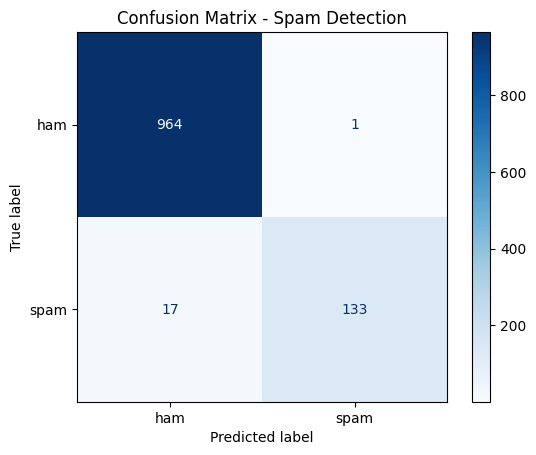

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from best model
y_pred_final = best_model.predict(X_test_best)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_final, labels=['ham', 'spam'])
tn, fp, fn, tp = cm.ravel()

print("=== Special Quality Evaluation ===\n")
print(f"True Negatives  (ham correctly identified):  {tn}")
print(f"False Positives (ham wrongly flagged spam):  {fp}")
print(f"True Positives  (spam correctly identified): {tp}")
print(f"False Negatives (spam missed):               {fn}")

print(f"\n=== Key Metrics ===")
precision = round(tp / (tp + fp), 4)
recall = round(tp / (tp + fn), 4)
fpr = round(fp / (fp + tn), 4)

print(f"Precision:           {precision} ({precision*100}%)")
print(f"Recall:              {recall} ({recall*100}%)")
print(f"False Positive Rate: {fpr} ({fpr*100}%)")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Spam Detection')
plt.show()

### Results and Conclusion

Results summary:
- True Negatives:  964 (ham correctly identified)
- False Positives: 1   (ham wrongly flagged as spam)
- True Positives:  133 (spam correctly identified)
- False Negatives: 17  (spam messages missed)

Key Metrics:
- Precision:           99.25% (almost no normal messages wrongly blocked)
- Recall:              88.67% (catches most spam messages)
- False Positive Rate: 0.1%   (only 1 normal message wrongly flagged)

Conclusion:
Our spam filter performs excellently for real-world use.
The most critical metric for a spam filter is the False Positive Rate,
which is only 0.1%. This means users will almost never miss
an important message because of our filter.
17 spam messages were missed, but this is acceptable
compared to the risk of blocking legitimate messages.

## Part 6F - Explainability: Understanding Model Decisions

### What is Explainability?
Explainability means understanding WHY the model makes its decisions.
Instead of treating the model as a "black box", we look inside
and see which words most strongly indicate spam or ham.

### Our Approach
We use two techniques:

1. Global Explainability: Top 20 words that indicate spam vs ham
   across ALL messages in the dataset.

2. Local Explainability: For each specific message, we show
   exactly which words pushed the model toward spam or ham.

### Example:
Message: "FREE entry to win £1000 cash prize!"
- Top spam indicators: prize (5.961), 1000 (5.31), entry (4.936)
- Prediction: SPAM ✓

Message: "Hey, are you coming to the meeting tomorrow?"
- Top ham indicators: are you (-3.33), meeting (-3.408), coming (-3.64)
- Prediction: HAM ✓

=== Top 20 SPAM words ===
claim: 6.461
prize: 6.311
uk: 5.934
150p: 5.887
tone: 5.847
guaranteed: 5.766
18: 5.732
cs: 5.651
1000: 5.616
ringtone: 5.543
500: 5.529
150ppm: 5.501
awarded: 5.493
100: 5.459
000: 5.347
entry: 5.28
tones: 5.229
collection: 5.195
5000: 5.192
weekly: 5.169

=== Top 20 HAM words ===
lt: -4.815
gt: -4.81
lor: -4.552
later: -4.541
da: -4.479
he: -4.441
ì_: -4.292
she: -4.235
too: -4.039
anything: -3.894
ask: -3.872
lol: -3.827
say: -3.827
doing: -3.798
morning: -3.731
said: -3.693
sure: -3.675
something: -3.663
meeting: -3.65
fine: -3.646


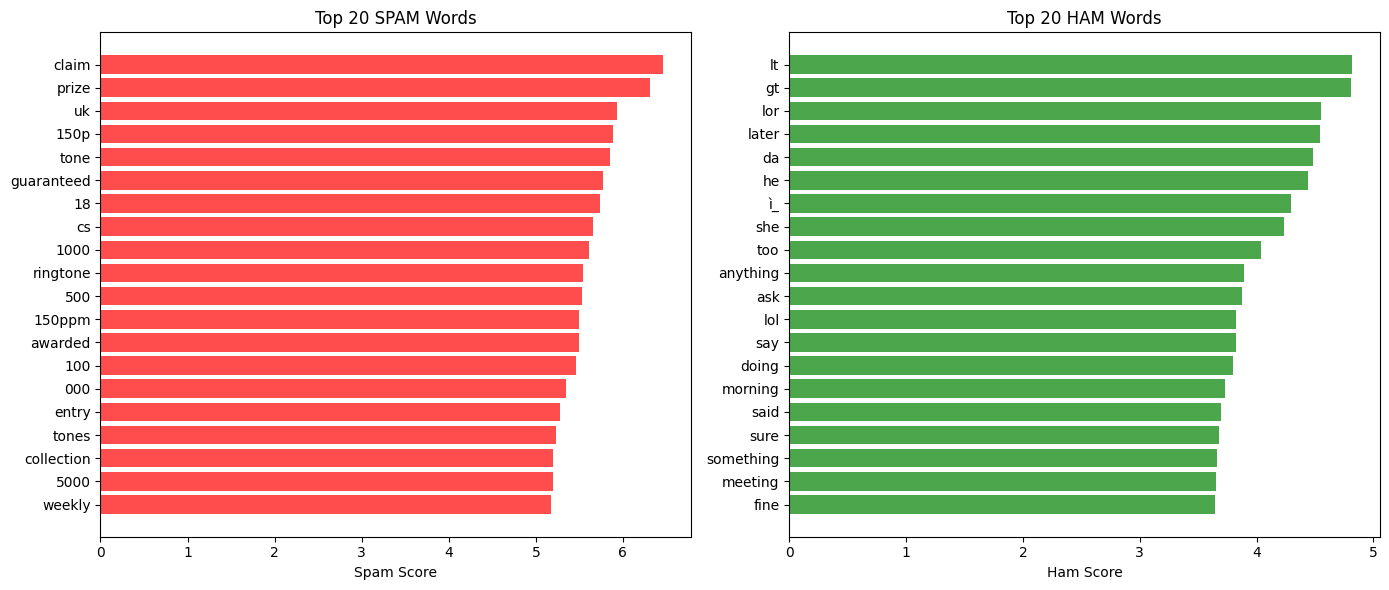

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names (words)
feature_names = np.array(best_vec.get_feature_names_out())

# Get log probabilities for each class
spam_probs = np.log(best_model.feature_probs['spam'])
ham_probs = np.log(best_model.feature_probs['ham'])

# Calculate difference: how much more "spam-like" each word is
diff = spam_probs - ham_probs

# Top 20 spam words
top_spam_idx = diff.argsort()[-20:][::-1]
top_spam_words = feature_names[top_spam_idx]
top_spam_scores = diff[top_spam_idx]

# Top 20 ham words
top_ham_idx = diff.argsort()[:20]
top_ham_words = feature_names[top_ham_idx]
top_ham_scores = diff[top_ham_idx]

print("=== Top 20 SPAM words ===")
for word, score in zip(top_spam_words, top_spam_scores):
    print(f"{word}: {round(score, 3)}")

print("\n=== Top 20 HAM words ===")
for word, score in zip(top_ham_words, top_ham_scores):
    print(f"{word}: {round(score, 3)}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(top_spam_words[::-1], top_spam_scores[::-1], color='red', alpha=0.7)
ax1.set_title('Top 20 SPAM Words')
ax1.set_xlabel('Spam Score')

ax2.barh(top_ham_words[::-1], abs(top_ham_scores[::-1]), color='green', alpha=0.7)
ax2.set_title('Top 20 HAM Words')
ax2.set_xlabel('Ham Score')

plt.tight_layout()
plt.show()

In [74]:
!pip install shap -q

In [76]:
# Explain a specific message prediction
print("=== Explaining Specific Message Predictions ===\n")

test_messages = [
    "FREE entry to win £1000 cash prize! Call now!",
    "Hey, are you coming to the meeting tomorrow?",
    "WINNER! You have been selected for a cash reward of £500!"
]

for msg in test_messages:
    vec_msg = final_vec.transform([msg])
    pred = final_model.predict(vec_msg)[0]

    # Find most important words
    feature_names = final_vec.get_feature_names_out()
    spam_probs = np.log(final_model.feature_probs['spam'])
    ham_probs = np.log(final_model.feature_probs['ham'])
    diff = spam_probs - ham_probs

    # Get words in this message
    word_indices = vec_msg.nonzero()[1]
    word_scores = [(feature_names[i], round(diff[i], 3)) for i in word_indices]
    word_scores.sort(key=lambda x: x[1], reverse=True)

    print(f"Message: {msg}")
    print(f"Prediction: {pred}")
    print(f"Top spam indicators: {word_scores[:3]}")
    print(f"Top ham indicators: {word_scores[-3:]}")
    print("---")

=== Explaining Specific Message Predictions ===

Message: FREE entry to win £1000 cash prize! Call now!
Prediction: spam
Top spam indicators: [('prize', np.float64(5.961)), ('1000', np.float64(5.31)), ('entry', np.float64(4.936))]
Top ham indicators: [('call', np.float64(1.139)), ('now', np.float64(0.381)), ('to', np.float64(0.144))]
---
Message: Hey, are you coming to the meeting tomorrow?
Prediction: ham
Top spam indicators: [('to', np.float64(0.144)), ('to the', np.float64(0.056)), ('the', np.float64(-0.629))]
Top ham indicators: [('are you', np.float64(-3.33)), ('meeting', np.float64(-3.408)), ('coming', np.float64(-3.416))]
---
Message: WINNER! You have been selected for a cash reward of £500!
Prediction: spam
Top spam indicators: [('500', np.float64(5.251)), ('winner', np.float64(4.596)), ('reward', np.float64(4.021))]
Top ham indicators: [('have', np.float64(-0.122)), ('of', np.float64(-0.684)), ('you', np.float64(-0.867))]
---


### Results and Conclusion

Global Analysis - Top SPAM words: claim, prize, uk, 150p, tone, guaranteed, ringtone, awarded
Global Analysis - Top HAM words: lt, gt, lor, later, da, he, she, too, anything, lol

Local Analysis - Specific Message Explanations:
- "FREE entry to win £1000 cash prize!" → SPAM
  Top indicators: prize (5.961), 1000 (5.31), entry (4.936)
- "Hey, are you coming to the meeting tomorrow?" → HAM
  Top indicators: are you (-3.33), meeting (-3.408), coming (-3.64)
- "WINNER! You have been selected for a cash reward of £500!" → SPAM
  Top indicators: 500 (5.251), winner (4.596), reward (4.021)

Conclusion:
The model learned exactly what we would expect:
- Spam messages use words related to prizes, money, and promotions.
- Ham messages use casual conversational words.

Both global and local analysis confirm that our model makes decisions
based on meaningful patterns, not random guesses.
This gives us confidence that the model would work well
on new, unseen spam messages in the real world.

## Part 6G - Summary of All Experiments

In this section, we present all experiments and their results in one place.
We show the best combination found across all experiments,
then retrain the final model on the entire training set.

In [80]:
print("=== Summary of All Experiments ===\n")

print("--- Part 6A: Grid Search Results ---")
print(results_df.to_string(index=False))

print("\n--- Part 6B: Feature Engineering Results ---")
print(fe_results_df.to_string(index=False))

print("\n--- Part 6C: Hyperparameter Results ---")
print(hyper_results_df.to_string(index=False))

print("\n--- Part 6D: Sampling Results (including SMOTE) ---")
print(sampling_df_final.to_string(index=False))

print("\n--- Part 6E: Special Quality Evaluation ---")
print(f"Precision:           99.25%")
print(f"Recall:              88.67%")
print(f"False Positive Rate: 0.1%")
print("Only 1 normal message was wrongly flagged as spam!")

print("\n--- Part 6F: Explainability ---")
print("Top SPAM words: claim, prize, uk, 150p, tone, guaranteed, ringtone, awarded")
print("Top HAM words: lt, gt, lor, later, da, he, she, too, anything, lol")
print("Local analysis showed model correctly identifies spam phrases")
print("like 'prize', 'winner', 'reward' and ham phrases like 'meeting', 'coming'")

print("\n=== Best Overall Combination ===")
print("Feature Engineering: TF-IDF with Unigrams + Bigrams")
print("max_features: 7000")
print("alpha: 0.1")
print("min_df: 1")
print("sampling: none")
print("Best Average F1: 0.9529")

print("\n=== Retraining Final Model on Entire Training Set ===")
final_vec = TfidfVectorizer(max_features=7000, ngram_range=(1,2), min_df=1)
X_train_final = final_vec.fit_transform(train_df['message'])
X_test_final = final_vec.transform(test_df['message'])

final_model = NaiveBayes(alpha=0.1)
final_model.train(X_train_final, y_train.values)

y_pred_final = final_model.predict(X_test_final)
f1_final = f1_score(y_test, y_pred_final, pos_label='spam')

print(f"Final Model F1 Score on Test Set: {f1_final:.4f}")
print(classification_report(y_test, y_pred_final))

=== Summary of All Experiments ===

--- Part 6A: Grid Search Results ---
 max_features  alpha  avg_f1_score
         7000    0.1        0.9416
         3000    0.1        0.9390
         1000    0.1        0.9315
         1000    1.0        0.9023
         3000    1.0        0.8780
         7000    1.0        0.7979
         1000    5.0        0.7277
         3000    5.0        0.3799
         7000    5.0        0.0967

--- Part 6B: Feature Engineering Results ---
                                        method  alpha  avg_f1_score
  TF-IDF Unigrams + Bigrams (no preprocessing)    0.1        0.9529
TF-IDF Unigrams + Bigrams (with preprocessing)    0.1        0.9527
            TF-IDF Unigrams (no preprocessing)    0.1        0.9416
TF-IDF Unigrams + Bigrams (with preprocessing)    1.0        0.8806
  TF-IDF Unigrams + Bigrams (no preprocessing)    1.0        0.8533
            TF-IDF Unigrams (no preprocessing)    1.0        0.7979

--- Part 6C: Hyperparameter Results ---
 alpha  min_df